In [125]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline
import numpy as np
import pandas as pd

In [133]:
words = open("names.txt", "r").read()
words = words.splitlines()

In [134]:
stoi = {ch: i for i,ch in enumerate(sorted(set(".".join(words))))}
stoi

{'.': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [135]:
itos = {i:ch for ch,i in stoi.items()}


In [136]:
N = torch.zeros((27,27), dtype=torch.int32)


In [137]:
for w in words:
    w = "."+w+"."
    for ch1, ch2 in zip(w,w[1:]):
        i = stoi[ch1]
        j = stoi[ch2]
        N[i, j] += 1



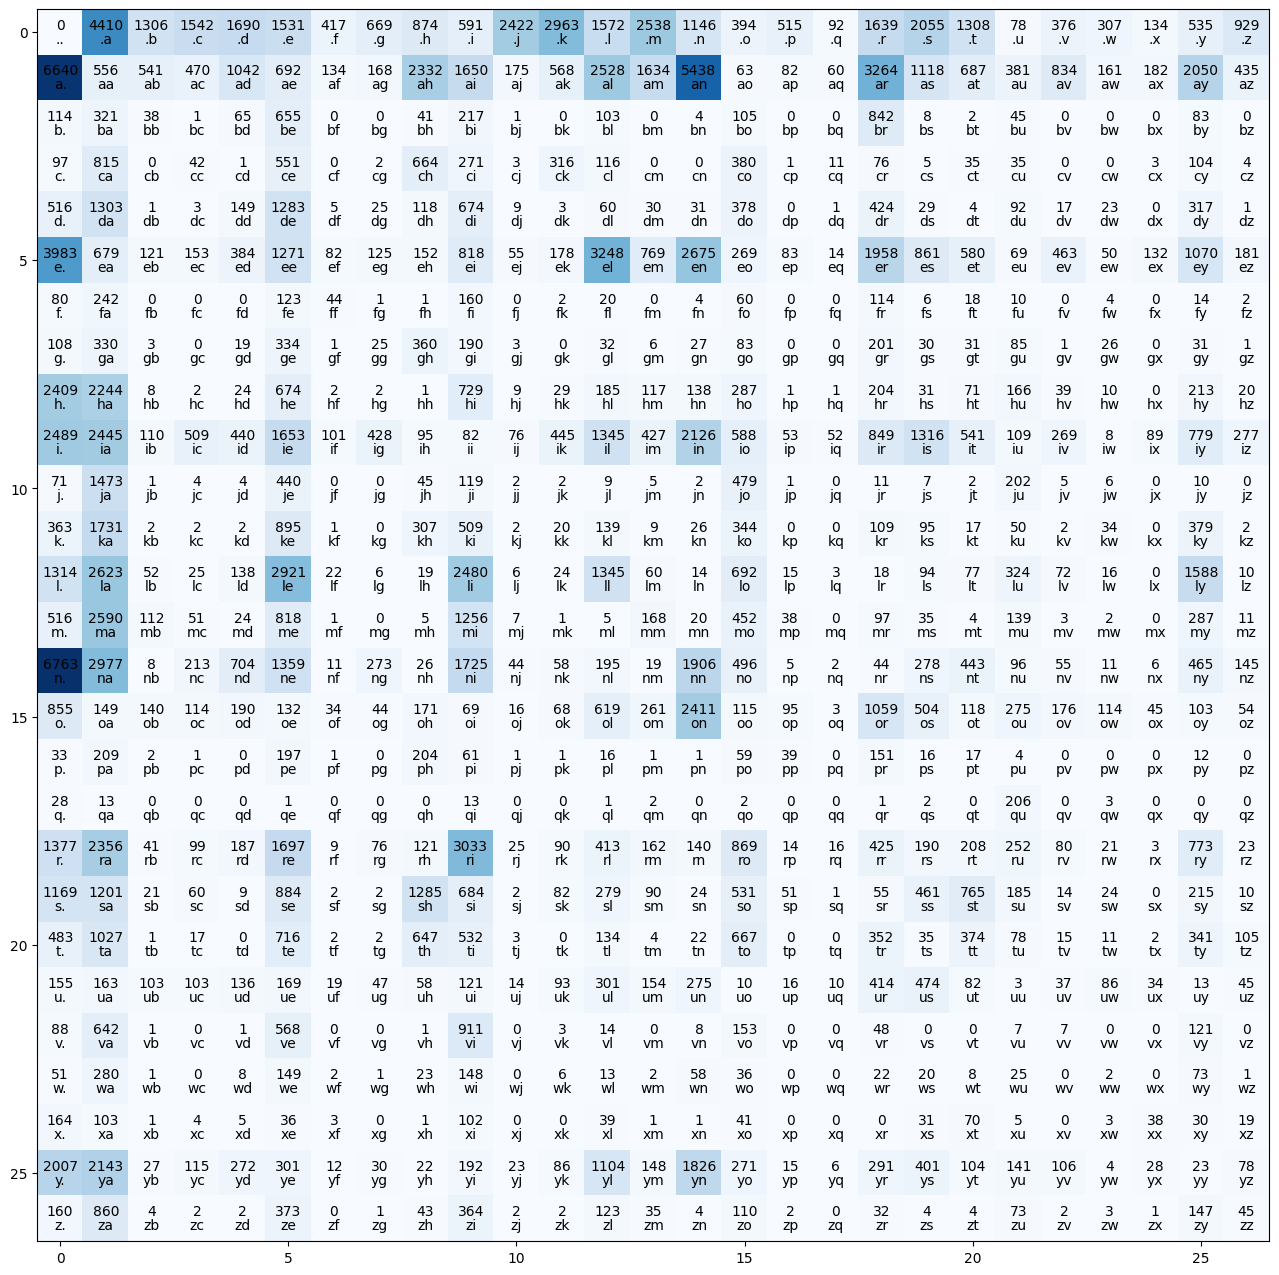

In [138]:
import matplotlib.pyplot as plt
plt.figure(figsize = (16, 16))
plt.imshow(N, cmap = "Blues",)
for i in range(N.shape[0]):
    for j in range(N.shape[1]):
        plt.text(j, i, str(N[i, j].item()), ha = "center", va = "bottom", color = "black")
        plt.text(j,i, str(itos[i])+str(itos[j]),va="top",ha = "center",color = "black")
plt.show()

In [139]:
N = N + 1

In [140]:
N = N / N.sum(1,keepdim=True)

In [141]:
g = torch.Generator().manual_seed(1000)
temp = torch.multinomial(N[0],replacement=True,num_samples=1,generator=g).item()
itos[temp]


'j'

In [142]:
out = ""
g = torch.Generator().manual_seed(1337)
ch = 0
for i in range(10):
    out=""
    while True:
        ch = torch.multinomial(N[ch],num_samples=1, replacement=True,generator=g).item()
        out += itos[ch]
        if ch == 0:
            break
    print(out)


gun.
kaneliy.
dy.
exylell.
eleleahmariss.
modarrinam.
rn.
vybeartosay.
kugr.
mare.


In [143]:
W = torch.randn((27,27),requires_grad=True)
print(W.shape)

torch.Size([27, 27])


In [166]:
ix  = []
iy = []
for w in words:
    w = "."+w+"."
    for ch1, ch2 in zip(w, w[1:]):
        ix.append(stoi[ch1])
        iy.append(stoi[ch2])

ix = torch.tensor(ix)
iy = torch.tensor(iy)
ix,iy

(tensor([ 0,  5, 13,  ..., 25, 26, 24]),
 tensor([ 5, 13, 13,  ..., 26, 24,  0]))

In [163]:
ll = 0.0
for ch1, ch2 in zip(ix,iy):
    loglogss = N[ch1,ch2]
    loglogss = torch.log(loglogss)
    ll+= loglogss
ll *=-1
ll = torch.tensor(ll)

ll = ll/ix.shape[0]
ll

C:\Users\KARTHIK\AppData\Local\Temp\ipykernel_37648\203812667.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ll = torch.tensor(ll)


tensor(2.4544)

In [250]:
ix  = []
iy = []
for w in words[:]:
    w = "."+w+"."
    for ch1, ch2 in zip(w, w[1:]):
        ix.append(stoi[ch1])
        iy.append(stoi[ch2])

ix = torch.tensor(ix)
iy = torch.tensor(iy)
ix,iy

(tensor([ 0,  5, 13,  ..., 25, 26, 24]),
 tensor([ 5, 13, 13,  ..., 26, 24,  0]))

In [251]:
import torch.nn.functional as F

input = F.one_hot(ix,num_classes=27).float()
input.shape

torch.Size([228146, 27])

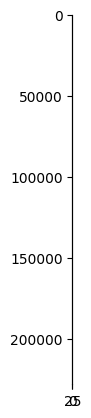

In [215]:
import matplotlib.pyplot as plt
plt.imshow(input)
plt.show()

In [255]:
W = torch.randn((27,27),dtype = torch.float32,requires_grad=True)

In [256]:
for i in range(400):
    input = F.one_hot(ix,num_classes=27,).float()
    logits = input @ W
    count = logits.exp()
    prob = count / count.sum(1,keepdim=True)
    ll = prob[torch.arange(ix.nelement()), iy]
    ll = -torch.log(ll).mean() + 0.01*(W**2).mean()
    W.grad = None
    ll.backward()
    W.data = W.data - 2*W.grad
    print(ll.item())


3.799787998199463
3.7824065685272217
3.765434503555298
3.748847723007202
3.732623338699341
3.7167422771453857
3.701188325881958
3.685946226119995
3.67100191116333
3.656343460083008
3.641960382461548
3.627842903137207
3.6139817237854004
3.6003682613372803
3.5869967937469482
3.5738582611083984
3.560948371887207
3.548259735107422
3.535787582397461
3.523526906967163
3.511472463607788
3.499619960784912
3.487964391708374
3.476503372192383
3.465230703353882
3.4541447162628174
3.4432408809661865
3.4325156211853027
3.4219658374786377
3.411588430404663
3.4013800621032715
3.3913378715515137
3.3814585208892822
3.3717401027679443
3.3621785640716553
3.352771759033203
3.3435168266296387
3.3344109058380127
3.3254523277282715
3.3166372776031494
3.3079636096954346
3.299429178237915
3.2910313606262207
3.2827672958374023
3.274634838104248
3.266631841659546
3.258755922317505
3.2510037422180176
3.2433741092681885
3.2358641624450684
3.2284717559814453
3.2211947441101074
3.2140302658081055
3.2069764137268066


In [260]:
W = torch.randn((27,27),dtype=torch.float32,requires_grad=True)
for i in range(500):
    input = F.one_hot(ix,num_classes=27).float()
    logits = input@W
    count = logits.exp()
    prob = count/count.sum(1,keepdim=True)
    loss = prob[torch.arange(ix.nelement()), iy]
    loss = -torch.log(loss).mean() + 0.01*(W**2).mean()
    W.grad = None
    print(loss.item())
    loss.backward()
    W.data -= 5*W.grad


3.8355062007904053
3.7918803691864014
3.749967575073242
3.709671974182129
3.6709163188934326
3.6336328983306885
3.597766399383545
3.5632662773132324
3.5300886631011963
3.4981932640075684
3.467540740966797
3.4380946159362793
3.4098172187805176
3.3826727867126465
3.356624126434326
3.331636667251587
3.307673931121826
3.2847015857696533
3.262685775756836
3.2415928840637207
3.221390962600708
3.2020480632781982
3.1835319995880127
3.1658124923706055
3.1488568782806396
3.1326327323913574
3.11710786819458
3.102247953414917
3.088020086288452
3.074389934539795
3.061323642730713
3.0487887859344482
3.0367531776428223
3.02518630027771
3.014059066772461
3.003345012664795
2.99301815032959
2.9830551147460938
2.9734344482421875
2.9641377925872803
2.955146074295044
2.946443557739258
2.9380152225494385
2.9298477172851562
2.921928882598877
2.9142472743988037
2.906792640686035
2.899555206298828
2.892526388168335
2.885697603225708
2.879061698913574
2.872610330581665
2.866337776184082
2.860236883163452
2.8543

In [271]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = ""
    ch = torch.tensor([0])
    while True:
        input = F.one_hot(ch,num_classes=27).float()
        logits = input @ W
        count = logits.exp()
        prob = count / count.sum(1,keepdim = True)
        ch = torch.multinomial(prob,num_samples=1,replacement=True,generator= g).item()
        output_char = itos[ch]
        out += output_char
        if ch == 0:
            break
        ch = torch.tensor([ch])
    print(out)



cexbr.
mogpsurailezityha.
kanimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavugn.
pteda.
ka.


# longer context

In [365]:
len = 3
ix = []
iy = []
for w in words[:1]:
    w = w + '.'
    cntx = [0]*len
    for ch in w:
        ix.append(cntx)
        iy.append(stoi[ch])
        cntx = cntx[1:] + [stoi[ch]]

ix = torch.tensor(ix)
iy = torch.tensor(iy)

ix,iy

(tensor([[ 0,  0,  0],
         [ 0,  0,  5],
         [ 0,  5, 13],
         [ 5, 13, 13],
         [13, 13,  1]]),
 tensor([ 5, 13, 13,  1,  0]))

In [371]:
W1 = torch.randn(6,100,requires_grad = True)
B1 = torch.randn(100,requires_grad=True)

W2 = torch.randn(100,27,requires_grad=True)
B2 = torch.randn(27,requires_grad=True)

In [372]:
emb = torch.randn(27,2)

In [373]:
input = emb[ix].view(-1,6)
input

tensor([[ 0.5914,  0.2973,  0.5914,  0.2973,  0.5914,  0.2973],
        [ 0.5914,  0.2973,  0.5914,  0.2973, -0.8404, -1.0883],
        [ 0.5914,  0.2973, -0.8404, -1.0883, -0.6161, -1.7319],
        [-0.8404, -1.0883, -0.6161, -1.7319, -0.6161, -1.7319],
        [-0.6161, -1.7319, -0.6161, -1.7319, -0.2074, -0.5048]])

In [374]:
logits  = input@ W1 + B1
logits = torch.tanh(logits)

logits2 = logits @ W2 + B2
logits2 = torch.tanh(logits2)
logits2 

tensor([[-1.0000, -1.0000,  0.6313,  0.9970,  1.0000, -1.0000, -0.7909, -1.0000,
          1.0000, -0.6342,  0.8366, -0.9998,  0.9343, -1.0000,  1.0000, -0.9997,
         -1.0000,  1.0000,  0.6376, -1.0000, -1.0000, -1.0000, -0.9915, -0.9709,
         -0.7720, -1.0000, -1.0000],
        [ 0.9971, -0.9997, -1.0000, -0.5882, -1.0000, -0.9999, -0.9988,  1.0000,
         -1.0000,  1.0000, -1.0000, -1.0000, -0.6688,  0.8862,  0.9974,  1.0000,
          0.9996,  1.0000, -0.9879, -0.9996, -0.9894, -1.0000,  1.0000,  1.0000,
         -0.9837, -0.9998,  1.0000],
        [ 0.5849,  1.0000, -0.0695, -1.0000, -1.0000,  0.2699,  1.0000,  1.0000,
         -1.0000,  1.0000, -1.0000,  0.8499,  1.0000,  1.0000,  0.7078,  1.0000,
          0.9940,  1.0000,  1.0000, -1.0000,  0.9898, -1.0000, -0.9946,  1.0000,
          0.9952,  1.0000, -0.9998],
        [-1.0000,  0.9641,  0.9762, -1.0000,  0.9739, -0.9883,  1.0000,  0.8487,
         -1.0000,  1.0000, -1.0000,  0.9993,  1.0000,  1.0000, -1.0000, -0.0688